# Customer Sales Analysis
Merging the churn/customer file with the sales file to look at top customers, monthly trends, regional performance and retention. Data is `customer_churn.csv` + `sales_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Day 1 - Load & Explore
Just getting the two files in and checking sizes / dtypes before doing anything else.

In [2]:
customers = pd.read_csv("customer_churn.csv")
sales = pd.read_csv("sales_data.csv")

print(customers.shape)
print(sales.shape)
customers.head()

(500, 9)
(100, 7)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# quick sanity check, no missing values but good habit to check anyway
print(customers.isna().sum())
print(sales.isna().sum())

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


## Day 2 - Cleaning & Prep
Fixing the ID mismatch between the two files, parsing dates, cleaning up text columns.

In [5]:
# the two files use different id formats (C00001 vs CUST001), gotta match them up
customers["CustomerKey"] = customers["CustomerID"].str.extract(r"(\d+)").astype(int)
sales["CustomerKey"] = sales["Customer_ID"].str.extract(r"(\d+)").astype(int)

# dates aren't parsed as dates yet
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["MonthName"] = sales["Date"].dt.month_name()
sales["Day"] = sales["Date"].dt.day
sales["Weekday"] = sales["Date"].dt.day_name()

# clean up text columns just in case of stray spaces/casing
for col in ["Contract", "PaymentMethod", "PaperlessBilling"]:
    customers[col] = customers[col].str.strip()
for col in ["Product", "Region"]:
    sales[col] = sales[col].str.strip().str.title()

customers["ContractSimple"] = customers["Contract"].str.replace("-", " ").str.lower()

sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,CustomerKey,Year,Month,MonthName,Day,Weekday
0,2024-01-01,Phone,7,37300,CUST001,East,261100,1,2024,1,January,1,Monday
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2,2024,1,January,2,Tuesday
2,2024-01-03,Phone,2,21746,CUST003,West,43492,3,2024,1,January,3,Wednesday
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,4,2024,1,January,4,Thursday
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,5,2024,1,January,5,Friday


## Day 3 - Customer Analysis
Top customers, lifetime value (proxied as total spend), regional split.

In [6]:
# merge sales onto customers so we know spend + churn together
merged = sales.merge(customers, on="CustomerKey", how="left")

# who spent the most overall
top_customers = (
    merged.groupby("Customer_ID")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_customers)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64


In [7]:
# customer lifetime value proxy = total spend per customer
clv = merged.groupby("Customer_ID").agg(
    TotalSpend=("Total_Sales", "sum"),
    Orders=("Total_Sales", "count"),
    AvgOrderValue=("Total_Sales", "mean"),
).sort_values("TotalSpend", ascending=False)
clv.head(10)

,TotalSpend,Orders,AvgOrderValue
Customer_ID,,,
CUST016,373932,1,373932.0
CUST007,363870,1,363870.0
CUST083,350888,1,350888.0
CUST073,349510,1,349510.0
CUST020,333992,1,333992.0
CUST084,324144,1,324144.0
CUST070,318762,1,318762.0
CUST005,318680,1,318680.0
CUST065,312564,1,312564.0


In [8]:
# regional split of revenue
region_sales = sales.groupby("Region")["Total_Sales"].agg(["sum", "mean", "count"])
region_sales.columns = ["TotalRevenue", "AvgOrderValue", "OrderCount"]
region_sales = region_sales.sort_values("TotalRevenue", ascending=False)
region_sales

,TotalRevenue,AvgOrderValue,OrderCount
Region,,,
North,3983635,142272.678571,28
South,3737852,138438.962963,27
East,2519639,132612.578947,19
West,2123922,81689.307692,26


## Day 4 - Sales Pattern Analysis
Monthly totals, best sellers, and a multi-condition filter example.

In [9]:
# group by month for the monthly totals theory concept
monthly_sales = sales.groupby(sales["Date"].dt.to_period("M"))["Total_Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales

Date
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Name: Total_Sales, dtype: int64

In [10]:
# best selling products (by revenue and by units)
product_performance = sales.groupby("Product").agg(
    Revenue=("Total_Sales", "sum"),
    UnitsSold=("Quantity", "sum"),
    Orders=("Total_Sales", "count"),
).sort_values("Revenue", ascending=False)
product_performance

,Revenue,UnitsSold,Orders
Product,,,
Laptop,3889210,136,24
Tablet,2884340,127,26
Phone,2859394,101,20
Headphones,1384033,48,15
Monitor,1348071,66,15


In [11]:
# multi condition filtering - big orders in the East or West region
big_orders = sales[(sales["Total_Sales"] > sales["Total_Sales"].median()) & ((sales["Region"] == "East") | (sales["Region"] == "West"))]
print(f"{len(big_orders)} orders match the filter")
big_orders.head()

20 orders match the filter


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,CustomerKey,Year,Month,MonthName,Day,Weekday
0,2024-01-01,Phone,7,37300,CUST001,East,261100,1,2024,1,January,1,Monday
9,2024-01-10,Laptop,4,45023,CUST010,West,180092,10,2024,1,January,10,Wednesday
12,2024-01-13,Phone,8,20655,CUST013,East,165240,13,2024,1,January,13,Saturday
20,2024-01-21,Laptop,3,36518,CUST021,East,109554,21,2024,1,January,21,Sunday
30,2024-01-31,Tablet,6,34900,CUST031,East,209400,31,2024,1,January,31,Wednesday


## Day 5 - Pivot Tables & Retention
Pivoting region x product, and estimating retention/churn by contract type + cross-sell pairs.

In [12]:
region_product_pivot = pd.pivot_table(
    sales, values="Total_Sales", index="Region", columns="Product", aggfunc="sum", fill_value=0
)
region_product_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [13]:
month_region_pivot = pd.pivot_table(
    sales, values="Total_Sales", index="MonthName", columns="Region", aggfunc="sum", fill_value=0
)
month_order = ["January", "February", "March", "April"]
month_region_pivot = month_region_pivot.reindex([m for m in month_order if m in month_region_pivot.index])
month_region_pivot

Region,East,North,South,West
MonthName,,,,
January,792969,1726624,1088182,512749
February,746674,640784,422941,845651
March,844016,1419350,1600314,621326
April,135980,196877,626415,144196


In [14]:
# retention rate, using the churn flag from the customer file
retention_by_contract = customers.groupby("Contract")["Churn"].agg(["mean", "count"])
retention_by_contract["RetentionRate"] = 1 - retention_by_contract["mean"]
retention_by_contract = retention_by_contract.rename(columns={"mean": "ChurnRate", "count": "Customers"})
retention_by_contract = retention_by_contract[["Customers", "ChurnRate", "RetentionRate"]]
retention_by_contract

,Customers,ChurnRate,RetentionRate
Contract,,,
Month-to-month,170,0.205882,0.794118
One year,186,0.043011,0.956989
Two year,144,0.069444,0.930556


In [15]:
overall_retention = 1 - customers["Churn"].mean()
print(f"Overall retention rate: {overall_retention:.1%}")

Overall retention rate: 89.4%


In [16]:
# cross-selling - which customers bought more than one product type
products_per_customer = sales.groupby("Customer_ID")["Product"].nunique()
cross_sell_customers = products_per_customer[products_per_customer > 1]
print(f"{len(cross_sell_customers)} customers bought 2+ different product types")

# which products tend to show up together for the same customer
from itertools import combinations
pair_counts = {}
for cust, group in sales.groupby("Customer_ID"):
    products = sorted(group["Product"].unique())
    for pair in combinations(products, 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1
pair_series = pd.Series(pair_counts).sort_values(ascending=False)
pair_series.head(10)

0 customers bought 2+ different product types


Series([], dtype: object)

## Day 6 - Dashboard
5 charts, different types, saved as one PNG.

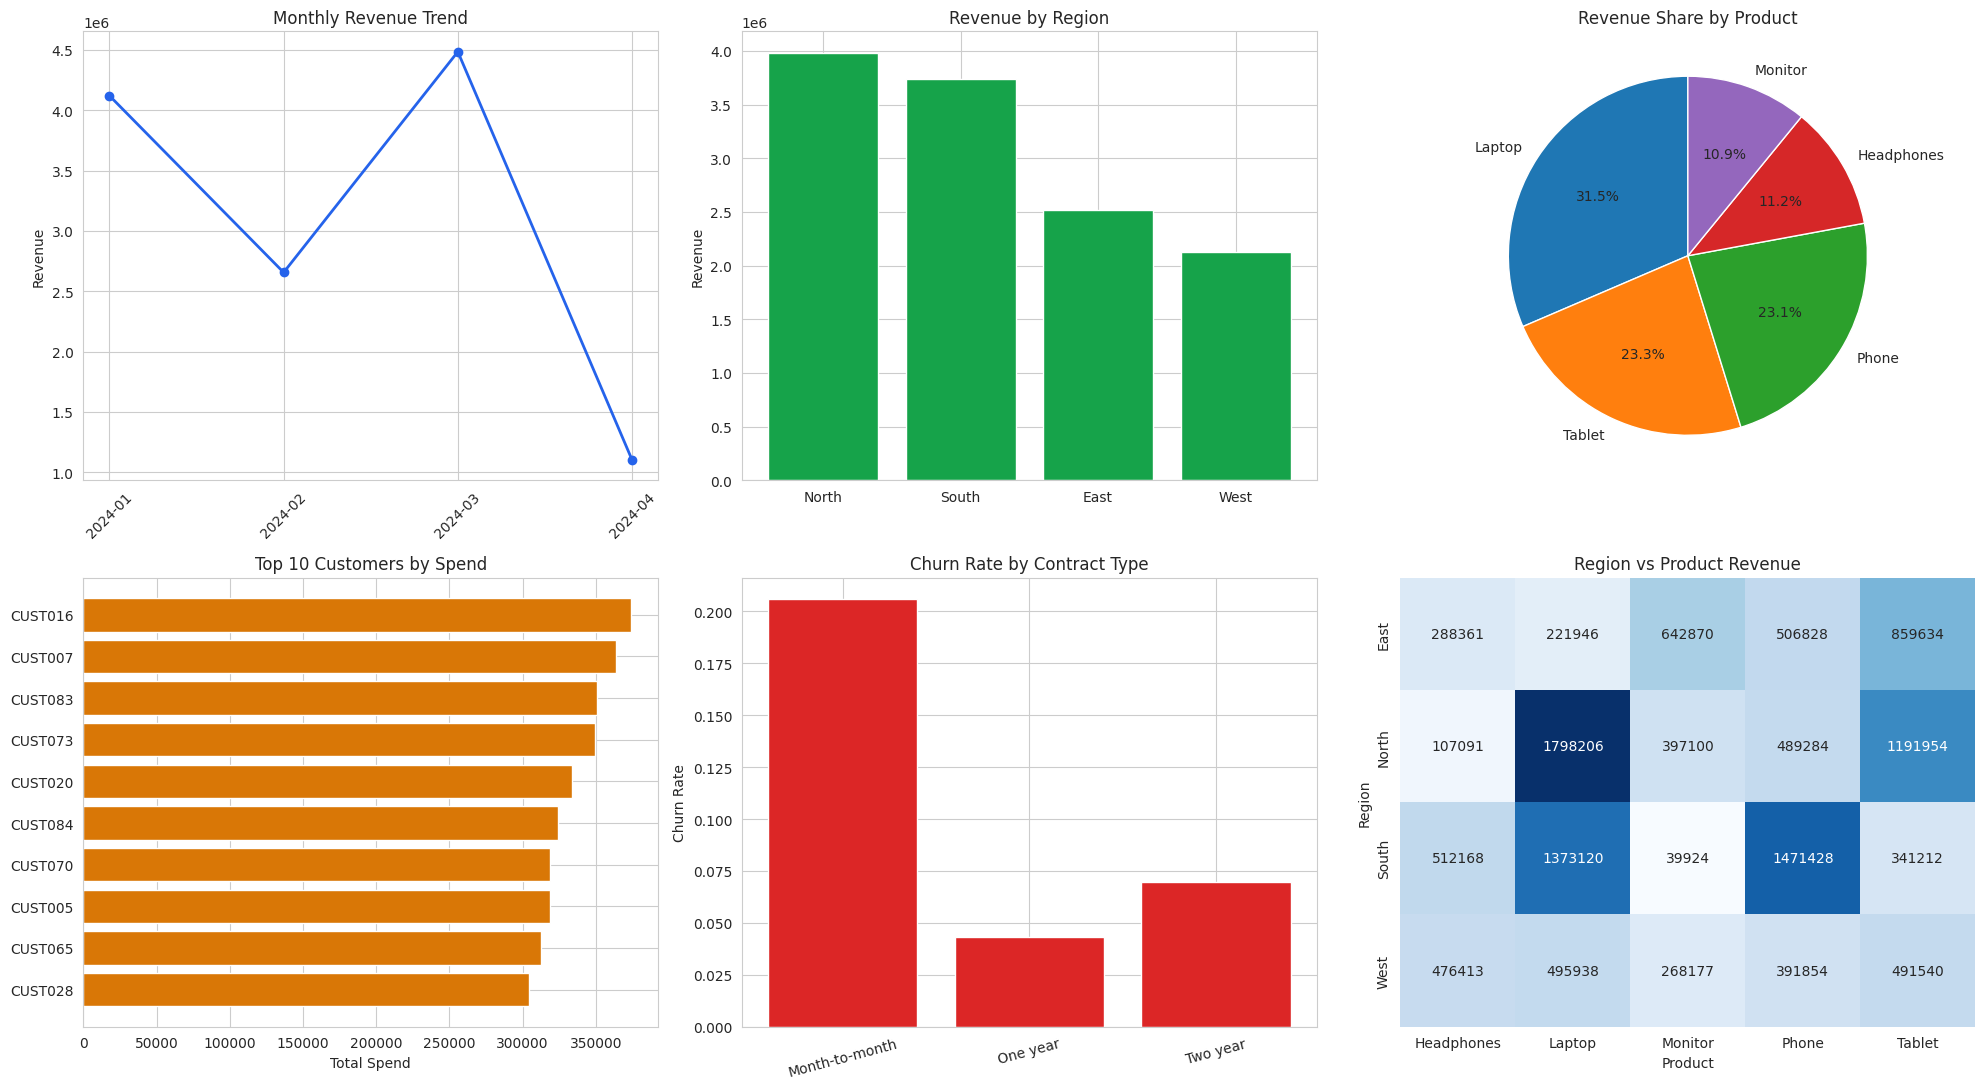

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. monthly revenue trend - line chart
axes[0, 0].plot(monthly_sales.index, monthly_sales.values, marker="o", linewidth=2, color="#2563eb")
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. revenue by region - bar chart
axes[0, 1].bar(region_sales.index, region_sales["TotalRevenue"], color="#16a34a")
axes[0, 1].set_title("Revenue by Region")
axes[0, 1].set_ylabel("Revenue")

# 3. revenue share by product - pie chart
axes[0, 2].pie(product_performance["Revenue"], labels=product_performance.index, autopct="%1.1f%%", startangle=90)
axes[0, 2].set_title("Revenue Share by Product")

# 4. top 10 customers - horizontal bar chart
top10 = clv.head(10).sort_values("TotalSpend")
axes[1, 0].barh(top10.index, top10["TotalSpend"], color="#d97706")
axes[1, 0].set_title("Top 10 Customers by Spend")
axes[1, 0].set_xlabel("Total Spend")

# 5. churn rate by contract type - bar chart
axes[1, 1].bar(retention_by_contract.index, retention_by_contract["ChurnRate"], color="#dc2626")
axes[1, 1].set_title("Churn Rate by Contract Type")
axes[1, 1].set_ylabel("Churn Rate")
axes[1, 1].tick_params(axis="x", rotation=15)

# 6. region x product heatmap
sns.heatmap(region_product_pivot, annot=True, fmt=".0f", cmap="Blues", ax=axes[1, 2], cbar=False)
axes[1, 2].set_title("Region vs Product Revenue")

plt.tight_layout()
plt.savefig("outputs/dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Day 7 - Summary Numbers
Pulling together the headline stats for the report.

In [18]:
total_revenue = sales["Total_Sales"].sum()
total_customers = customers["CustomerID"].nunique()
avg_order_value = sales["Total_Sales"].mean()
top_customer_id = clv.index[0]
top_customer_spend = clv.iloc[0]["TotalSpend"]

print("CUSTOMER SALES ANALYSIS REPORT")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Total Customers (in churn file): {total_customers:,}")
print(f"Customers with matching sales activity: {sales['Customer_ID'].nunique()}")
print(f"Average Order Value: ${avg_order_value:,.0f}")
print(f"Top Customer: {top_customer_id} - ${top_customer_spend:,.0f}")
print(f"Overall Retention Rate: {overall_retention:.1%}")

CUSTOMER SALES ANALYSIS REPORT
Total Revenue: $12,365,048
Total Customers (in churn file): 500
Customers with matching sales activity: 100
Average Order Value: $123,650
Top Customer: CUST016 - $373,932
Overall Retention Rate: 89.4%
